In [1]:
!pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.4 MB/s eta 0:00:00


In [2]:
import zipfile
import os

zip_file = "Humidity.zip"
extract_folder = "humidity"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files extracted:")
print(os.listdir(extract_folder))

Files extracted:
['RH-2m_2020050213_ncum_imdaa_reanl_2df_13.nc', 'RH-2m_2020050109_ncum_imdaa_reanl_2df_09.nc', 'RH-2m_2020050122_ncum_imdaa_reanl_2df_22.nc', 'RH-2m_2020050209_ncum_imdaa_reanl_2df_09.nc', 'RH-2m_2020050113_ncum_imdaa_reanl_2df_13.nc', 'RH-2m_2020050222_ncum_imdaa_reanl_2df_22.nc']


In [3]:
import xarray as xr

In [5]:
ds = xr.open_dataset("humidity/RH-2m_2020050109_ncum_imdaa_reanl_2df_09.nc")

In [6]:
ds

<xarray.Dataset> Size: 760B
Dimensions:  (time: 1, height: 1, lat: 8, lon: 17)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-05-01T09:00:00
  * height   (height) float64 8B 2.0
  * lat      (lat) float64 64B 28.08 28.2 28.32 28.44 28.56 28.68 28.8 28.92
  * lon      (lon) float64 136B 76.08 76.2 76.32 76.44 ... 77.76 77.88 78.0
Data variables:
    2r       (time, height, lat, lon) float32 544B ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Jul 06 11:07:40 2026: cdo -f nc4c -z zip_4 sellonlatbox...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [7]:
ds["2r"]

<xarray.DataArray '2r' (time: 1, height: 1, lat: 8, lon: 17)> Size: 544B
[136 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-05-01T09:00:00
  * height   (height) float64 8B 2.0
  * lat      (lat) float64 64B 28.08 28.2 28.32 28.44 28.56 28.68 28.8 28.92
  * lon      (lon) float64 136B 76.08 76.2 76.32 76.44 ... 77.76 77.88 78.0
Attributes:
    standard_name:  relative_humidity
    long_name:      2 metre relative humidity
    units:          %
    param:          1.1.0

In [8]:
print(ds["2r"].values)

[[[[12.      11.96875 12.      12.      12.03125 12.09375 12.0625
    12.28125 12.15625 11.71875 12.25    13.1875  14.34375 15.5625
    16.625   18.03125 19.96875]
   [12.46875 11.90625 12.      12.      12.      11.90625 11.90625
    12.375   12.625   12.59375 13.59375 14.8125  15.96875 17.15625
    18.34375 19.96875 21.25   ]
   [11.78125 11.875   11.90625 12.      12.      11.90625 11.84375
    12.1875  12.96875 14.      15.34375 16.5625  17.46875 18.5625
    20.21875 21.75    24.0625 ]
   [11.75    11.8125  11.90625 12.      12.15625 12.34375 12.21875
    13.15625 14.46875 16.03125 17.5     18.21875 18.71875 20.21875
    22.34375 23.      27.21875]
   [11.8125  11.90625 11.9375  12.0625  12.25    12.46875 13.125
    14.84375 16.75    18.59375 19.8125  19.5     19.53125 21.625
    23.96875 25.28125 28.25   ]
   [12.0625  12.03125 12.      12.15625 12.65625 13.1875  14.34375
    16.75    19.78125 21.625   22.40625 20.84375 20.28125 22.5625
    25.75    28.1875  31.3125 ]
   [12.15625

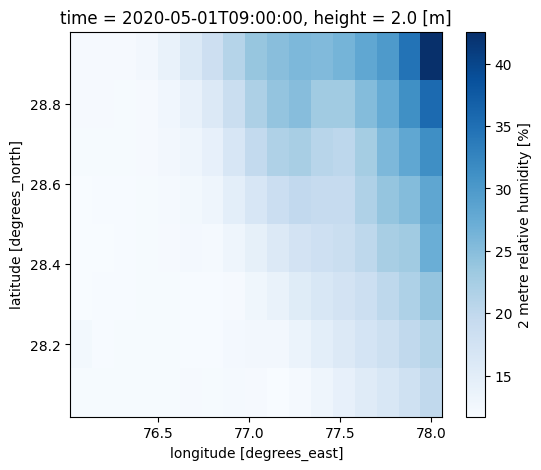

In [9]:
ds["2r"].plot(figsize=(6,5), cmap="Blues")

In [10]:
print("Minimum RH:", ds["2r"].min().values)
print("Maximum RH:", ds["2r"].max().values)
print("Mean RH:", ds["2r"].mean().values)

Minimum RH: 11.71875
Maximum RH: 42.5625
Mean RH: 17.226102828979492
